# Linear Support Vector Machine (SVM) Model

In [2]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [3]:
iris = datasets.load_iris()

In [4]:
X = iris["data"][:,(2, 3)] # petal length and petal width
y = (iris["target"] == 2).astype(np.float64) # Iris virginica

In [5]:
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge")),
])

In [6]:
svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [7]:
from sklearn.model_selection import cross_val_score

cross_val_score(svm_clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

array([0.96666667, 0.96666667, 1.        , 0.86666667, 0.96666667])

In [8]:
#Create a set of predictions ot compare with the actual targets
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(svm_clf, X, y, cv=5, n_jobs=-1)

In [9]:
#Create the confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y, y_pred)

array([[97,  3],
       [ 4, 46]])

In [10]:
#Fine-tune SVM model with Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"C": [1, 5, 10, 25, 50, 75, 100]},
]

svm_clf2 = LinearSVC(loss="hinge")

grid_search = GridSearchCV(svm_clf2, param_grid, cv=5,
                           scoring="accuracy",
                           return_train_score=True,
                           n_jobs=-1
                           )

grid_search.fit(X, y)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


GridSearchCV(cv=5, estimator=LinearSVC(loss='hinge'), n_jobs=-1,
             param_grid=[{'C': [1, 5, 10, 25, 50, 75, 100]}],
             return_train_score=True, scoring='accuracy')

In [11]:
svm_clf_better = LinearSVC(C=100, loss='hinge')
svm_clf_better.fit(X, y)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=100, loss='hinge')

In [12]:
cross_val_score(svm_clf_better, X, y, cv=5, scoring='accuracy', n_jobs=-1)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


array([0.93333333, 1.        , 0.83333333, 0.86666667, 1.        ])

In [13]:
y_pred_better = cross_val_predict(svm_clf_better, X, y, cv=5, n_jobs=-1)
confusion_matrix(y, y_pred_better)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


array([[89, 11],
       [ 2, 48]])

Nonlinear SVM Classification

In [14]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [15]:
X, y = make_moons(n_samples=100, noise=0.15)

In [16]:
polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge"))
])

In [17]:
polynomial_svm_clf.fit(X, y)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge'))])

In [18]:
from sklearn.model_selection import cross_val_score

cross_val_score(polynomial_svm_clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


array([1.  , 1.  , 1.  , 0.95, 0.95])

In [19]:
import matplotlib.pyplot as plt

In [21]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

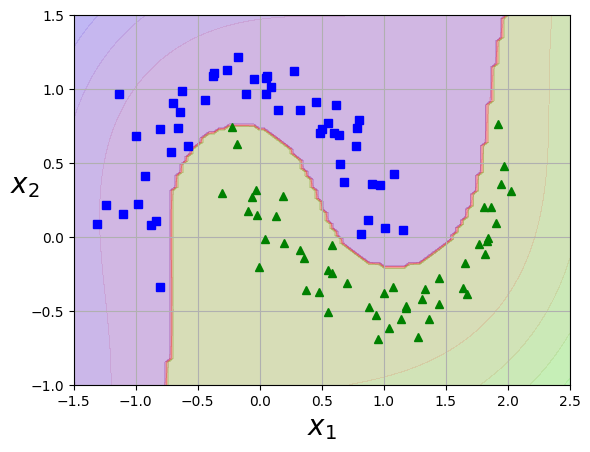

In [22]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

plt.show()